# Fase 4 · Análisis de sensibilidad

**Universidad:** UNIFRANZ — **Materia:** Minería de Datos.

**Integrantes:** Milenka Melody Chuquimia Osco; Edson Teddy Tito Chuquimia; Carlos Daniel Valverde Mendoza; Alvaro Luis Carlos del Carpio Blanco; Marcelo Josue Escobar Chipana.

Clasificación retrospectiva de registros completos. La población corresponde a los estudiantes universitarios representados en el CSV. La etiqueta no es un diagnóstico clínico. No se demuestra causalidad, representatividad institucional ni detección anticipada. El KPI descriptivo es 24,974 % de etiquetas High; no mide calidad predictiva.


## Objetivo y diseño comparable

Comparar los tres clasificadores retirando Post_Semester_GPA y Skill_Retention_Score. Se mantienen filas, orden, pliegues, espacios, combinaciones y presupuestos. Se adapta un preprocesador nuevo dentro de Fase 4, sin editar Fase 3. Este escenario de 12 predictores no participa en la selección principal. No demuestra detección anticipada: otros campos también tienen tiempos de medición desconocidos.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "wrangler/03_PREPARACION_DATOS/artefactos/manifest.json").is_file())
sys.path.insert(0, str(ROOT / "wrangler/04_MODELADO"))
from eduanalytics_modelado import core
from eduanalytics_modelado.academico import texto, metricas, matrices, presentar_modelo, presentar_comparacion
import pandas as pd
from IPython.display import display
entradas = core.verificar_entradas()
print("Python:", core.versiones()["Python"], "scikit-learn:", core.versiones()["scikit-learn"])
print("CSV:", entradas["input"]["path"], "SHA-256:", entradas["input"]["sha256"])
directory = core.experimento_actual()
X, y, trace = core.cargar("train", "reducido")
print("Escenario reducido:", X.shape)
display(list(X.columns))
display(core.crear_pipeline("logistica", "reducido"))

Python: 3.10.6 scikit-learn: 1.7.2
CSV: dataset/ai_student_impact_dataset (1).csv SHA-256: 585c433cf9b447df6812c76dbb6732d2bb663689a7b595a9a4b5d777fea991d5
Escenario reducido: (35000, 12)


['Major_Category',
 'Year_of_Study',
 'Pre_Semester_GPA',
 'Weekly_GenAI_Hours',
 'Primary_Use_Case',
 'Prompt_Engineering_Skill',
 'Tool_Diversity',
 'Paid_Subscription',
 'Traditional_Study_Hours',
 'Perceived_AI_Dependency',
 'Institutional_Policy',
 'Anxiety_Level_During_Exams']

,steps,"[('preprocesamiento', ...), ('clasificador', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('columnas', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numericas', ...), ('categoricas', ...), ...]"
,remainder,'drop'
,sparse_threshold,0


## Ejecución de los tres experimentos reducidos

Cada búsqueda recibe un pipeline completo; escalado y categorías se aprenden dentro de CV. La mejora o caída respecto del principal no prueba que esas dos variables formen parte de la construcción de la etiqueta.

,model,scenario,params,cv_macro_f1,cv_std,train_macro_f1,validation_macro_f1,validation_accuracy,gap,search_seconds,...,support_Low,precision_Medium,recall_Medium,f1_Medium,support_Medium,precision_High,recall_High,f1_High,support_High,interpretability
0,dummy,principal,{},0.198135,0.000019,0.198135,0.198151,0.422933,-0.000016,0.394543,...,2455,0.422933,1.000000,0.594453,3172,0.000000,0.000000,0.000000,1873,Regla mayoritaria
1,logistica,principal,"{""clasificador__C"":100,""clasificador__class_we...",0.539575,0.003304,0.540808,0.534845,0.533733,0.005963,16.719550,...,2455,0.485988,0.606873,0.539745,3172,0.663941,0.476775,0.555003,1873,Coeficientes regularizados; frontera conjunta
2,arbol,principal,"{""clasificador__ccp_alpha"":0.0,""clasificador__...",0.524107,0.005165,0.533612,0.533385,0.525733,0.000227,27.546804,...,2455,0.494094,0.474779,0.484244,3172,0.622404,0.528030,0.571346,1873,Reglas de divisiones y hojas
3,random_forest,principal,"{""clasificador__class_weight"":null,""clasificad...",0.537131,0.004798,0.562972,0.534054,0.531467,0.028918,745.917773,...,2455,0.484872,0.596154,0.534785,3172,0.663762,0.487987,0.562462,1873,Conjunto; importancias globales
4,logistica,reducido,"{""clasificador__C"":10,""clasificador__class_wei...",0.539967,0.003701,0.540851,0.535526,0.534400,0.005325,14.735367,...,2455,0.487005,0.608449,0.540995,3172,0.666915,0.477843,0.556765,1873,Coeficientes regularizados; frontera conjunta
5,arbol,reducido,"{""clasificador__ccp_alpha"":0.0,""clasificador__...",0.526106,0.007276,0.533612,0.533385,0.525733,0.000227,24.968810,...,2455,0.494094,0.474779,0.484244,3172,0.622404,0.528030,0.571346,1873,Reglas de divisiones y hojas
6,random_forest,reducido,"{""clasificador__class_weight"":null,""clasificad...",0.537119,0.005011,0.561689,0.536140,0.533067,0.025549,573.759455,...,2455,0.485795,0.593001,0.534072,3172,0.664978,0.490657,0.564670,1873,Conjunto; importancias globales


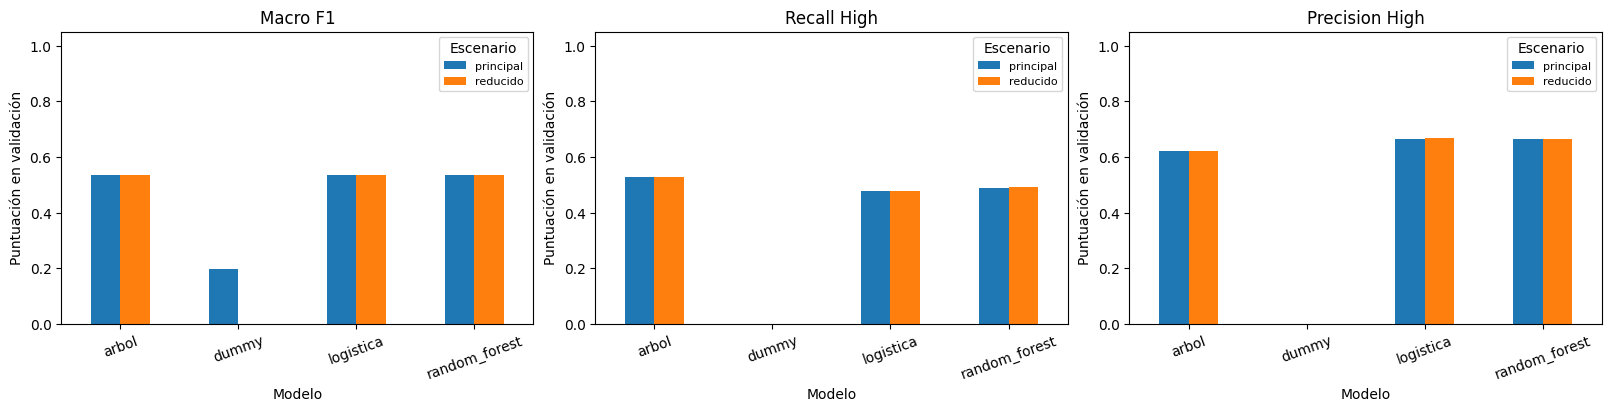

,validation_macro_f1,recall_High,precision_High
modelo,,,
arbol,0.000000,0.000000,0.000000
logistica,0.000681,0.001068,0.002975
random_forest,0.002086,0.002670,0.001216


Las diferencias son reducido−principal, sobre las mismas particiones, pliegues, espacios y presupuestos. Retirar GPA final y retención analiza sensibilidad; no garantiza disponibilidad anticipada de los restantes campos ni elimina circularidad con una etiqueta de fórmula desconocida. Las figuras tienen la misma escala.

,model,scenario,params,cv_macro_f1,cv_std,train_macro_f1,validation_macro_f1,validation_accuracy,gap,search_seconds,...,f1_Low,support_Low,precision_Medium,recall_Medium,f1_Medium,support_Medium,precision_High,recall_High,f1_High,support_High
0,dummy,principal,{},0.198135,0.000019,0.198135,0.198151,0.422933,-0.000016,0.394543,...,0.000000,2455,0.422933,1.000000,0.594453,3172,0.000000,0.000000,0.000000,1873
1,logistica,principal,"{""clasificador__C"":100,""clasificador__class_we...",0.539575,0.003304,0.540808,0.534845,0.533733,0.005963,16.719550,...,0.509787,2455,0.485988,0.606873,0.539745,3172,0.663941,0.476775,0.555003,1873
2,arbol,principal,"{""clasificador__ccp_alpha"":0.0,""clasificador__...",0.524107,0.005165,0.533612,0.533385,0.525733,0.000227,27.546804,...,0.544566,2455,0.494094,0.474779,0.484244,3172,0.622404,0.528030,0.571346,1873
3,random_forest,principal,"{""clasificador__class_weight"":null,""clasificad...",0.537131,0.004798,0.562972,0.534054,0.531467,0.028918,745.917773,...,0.504917,2455,0.484872,0.596154,0.534785,3172,0.663762,0.487987,0.562462,1873
4,logistica,reducido,"{""clasificador__C"":10,""clasificador__class_wei...",0.539967,0.003701,0.540851,0.535526,0.534400,0.005325,14.735367,...,0.508817,2455,0.487005,0.608449,0.540995,3172,0.666915,0.477843,0.556765,1873
5,arbol,reducido,"{""clasificador__ccp_alpha"":0.0,""clasificador__...",0.526106,0.007276,0.533612,0.533385,0.525733,0.000227,24.968810,...,0.544566,2455,0.494094,0.474779,0.484244,3172,0.622404,0.528030,0.571346,1873
6,random_forest,reducido,"{""clasificador__class_weight"":null,""clasificad...",0.537119,0.005011,0.561689,0.536140,0.533067,0.025549,573.759455,...,0.509679,2455,0.485795,0.593001,0.534072,3172,0.664978,0.490657,0.564670,1873


In [2]:
for modelo in core.MODELOS:
    core.entrenar(modelo, "reducido", directory)
presentar_comparacion(directory, sensibilidad=True)

## Resultados detallados por familia

Se incluyen búsquedas, matrices, métricas, brechas e interpretación del escenario reducido.

### Categorías desconocidas y controles de entrada

,variable,registros_desconocidos_validación
0,Major_Category,0
1,Year_of_Study,0
2,Primary_Use_Case,0
3,Prompt_Engineering_Skill,0
4,Institutional_Policy,0


Se observaron **0 incidencias** de categorías de validación ausentes en entrenamiento. La política `handle_unknown="ignore"` representa una desconocida mediante ceros; su prueba dirigida utiliza un caso artificial separado.

### Búsqueda y configuración seleccionada

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_clasificador__C,param_clasificador__class_weight,params,split0_test_score,split1_test_score,split2_test_score,...,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score,configuration_index
0,0.139996,0.008375,0.032993,0.004722,10.00,NaN,"{""clasificador__C"":10,""clasificador__class_wei...",0.543835,0.541590,0.536373,...,0.003701,1,0.540154,0.540462,0.541849,0.540138,0.542386,0.540998,0.000937,6
1,0.133814,0.012843,0.027654,0.000536,100.00,NaN,"{""clasificador__C"":100,""clasificador__class_we...",0.543835,0.541590,0.536373,...,0.003701,1,0.540119,0.540462,0.541849,0.540138,0.542352,0.540984,0.000933,8
2,0.156166,0.022356,0.033517,0.005639,1.00,NaN,"{""clasificador__C"":1,""clasificador__class_weig...",0.543948,0.541590,0.536394,...,0.003697,3,0.540154,0.540496,0.541662,0.540165,0.542386,0.540973,0.000897,4
3,0.170529,0.017562,0.035214,0.002868,0.10,NaN,"{""clasificador__C"":0.1,""clasificador__class_we...",0.543618,0.541526,0.535801,...,0.003905,4,0.540009,0.540428,0.541563,0.540225,0.542252,0.540895,0.000865,2
4,0.165023,0.004656,0.029457,0.001582,0.01,NaN,"{""clasificador__C"":0.01,""clasificador__class_w...",0.541992,0.541561,0.530808,...,0.004617,5,0.539115,0.538645,0.539996,0.538234,0.540215,0.539241,0.000762,0
5,0.128159,0.007514,0.030272,0.004876,10.00,balanced,"{""clasificador__C"":10,""clasificador__class_wei...",0.516133,0.521311,0.512190,...,0.003585,6,0.517719,0.515752,0.520458,0.517069,0.520231,0.518246,0.001829,7
6,0.139747,0.022283,0.032221,0.006389,100.00,balanced,"{""clasificador__C"":100,""clasificador__class_we...",0.516133,0.521311,0.512190,...,0.003585,6,0.517719,0.515752,0.520458,0.517110,0.520231,0.518254,0.001823,9
7,0.133760,0.004652,0.031322,0.003450,1.00,balanced,"{""clasificador__C"":1,""clasificador__class_weig...",0.516133,0.521049,0.512031,...,0.003537,8,0.517719,0.515752,0.520415,0.517100,0.520233,0.518244,0.001815,5
8,0.143661,0.008342,0.032577,0.004264,0.10,balanced,"{""clasificador__C"":0.1,""clasificador__class_we...",0.516027,0.520239,0.512215,...,0.003310,9,0.517700,0.515204,0.520426,0.517001,0.520261,0.518118,0.001991,3
9,0.167499,0.008524,0.031805,0.004583,0.01,balanced,"{""clasificador__C"":0.01,""clasificador__class_w...",0.516755,0.520338,0.512296,...,0.003237,10,0.517101,0.515462,0.519913,0.515838,0.519858,0.517635,0.001917,1


,parámetro,valor
0,clasificador__C,10
1,clasificador__class_weight,None


Se completaron **10 configuraciones** y **51 ajustes**. CV Macro F1 = **0.539967**, DE = **0.003701**. Esta media selecciona hiperparámetros; no evalúa independientemente al ganador. La desviación entre cinco pliegues no es un intervalo de confianza.

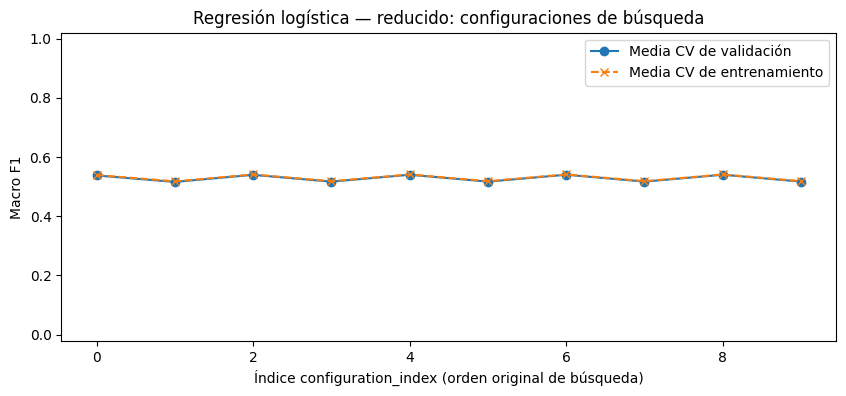

La configuración de índice **6** obtiene la mejor media CV. Las curvas muestran ajuste y validación dentro de entrenamiento; el eje no es una escala de complejidad.

### Diagnóstico en entrenamiento y comparación en validación fija

,partición,Macro F1,Accuracy
0,train,0.540851,0.539543
1,validation,0.535526,0.534400


,f1,precision,precision_undefined,recall,support
Low,0.508817,0.538952,False,0.481874,2455
Medium,0.540995,0.487005,False,0.608449,3172
High,0.556765,0.666915,False,0.477843,1873


Macro F1 = **0.535526**, Accuracy = **0.534400**. High: Precision **0.666915** y Recall **0.477843**. El soporte representa registros de cada etiqueta.

Brecha Macro F1 entrenamiento−validación = **0.005325**. Una brecha positiva señala un posible sobreajuste; una brecha pequeña tampoco garantiza generalización externa.

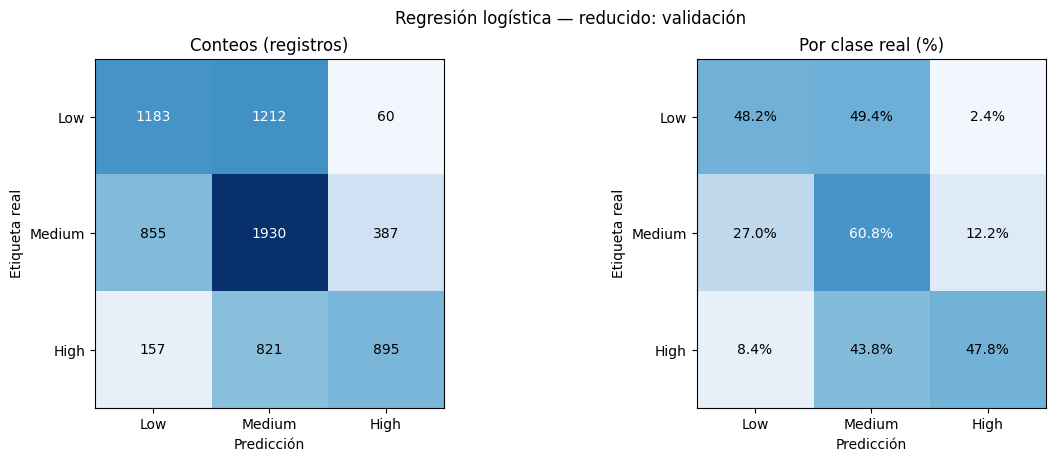

High→Low: **157**; High→Medium: **821**. Low→High: **60**; Medium→High: **387**. Los primeros son falsos negativos de High y los últimos falsos positivos. La normalización muestra la fracción de cada clase real. Un mayor Recall puede acompañarse de menor Precision; la matriz permite localizar ese compromiso.

,fits,inference_includes,search_and_refit_seconds,selected_refit_seconds,started_utc,train_inference_seconds,validation_inference_seconds
0,51,predict and predict_proba; full pipeline,14.735367,0.1594,2026-10-09T19:55:01.133785+00:00,0.068232,0.021224


Los tiempos incluyen el preprocesamiento. Son observaciones de esta ejecución y equipo, no constantes reproducibles.

### Interpretabilidad

,class,feature,coefficient
0,High,numericas__Pre_Semester_GPA,-0.178650
1,High,numericas__Weekly_GenAI_Hours,0.779034
2,High,numericas__Tool_Diversity,0.001475
3,High,numericas__Traditional_Study_Hours,-0.115556
4,High,numericas__Perceived_AI_Dependency,0.183834
...,...,...,...
79,Medium,categoricas__Prompt_Engineering_Skill_Intermed...,0.059564
80,Medium,categoricas__Institutional_Policy_Actively_Enc...,0.101120
81,Medium,categoricas__Institutional_Policy_Allowed_With...,0.120696
82,Medium,categoricas__Institutional_Policy_Strict_Ban,-0.018802


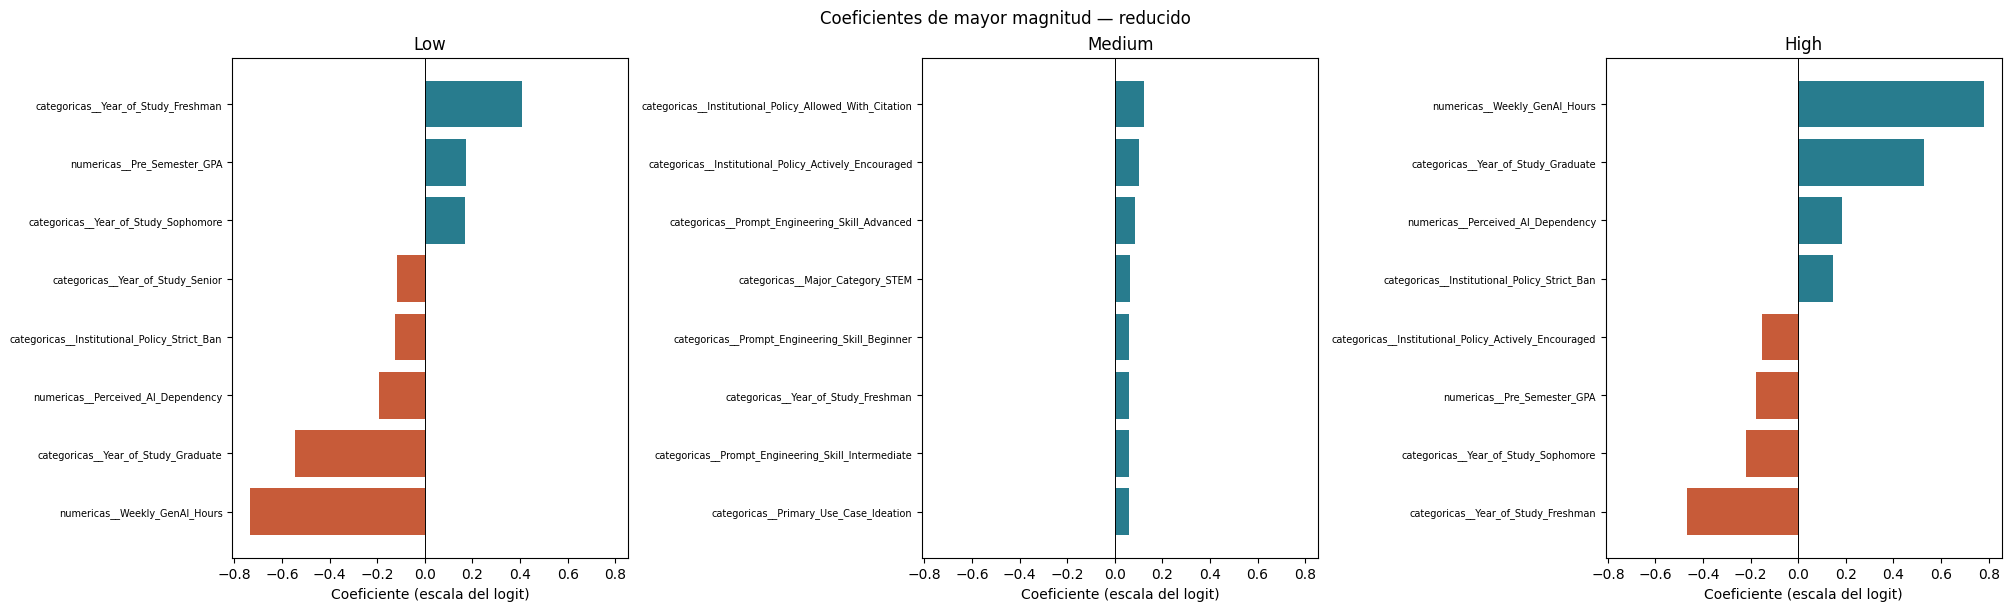

Convergencia: **True**, iteraciones **[17]** de máximo 5000. Las numéricas están estandarizadas dentro del entrenamiento correspondiente. L2 reduce magnitudes; con todas las categorías one-hot no hay una categoría de referencia eliminada. Los coeficientes forman una decisión conjunta multinomial y no prueban efectos causales ni una comparación inequívoca aislada.

### Conclusión del experimento
Macro F1 de validación **0.535526**; Recall de High **0.477843**. El resultado corresponde a etiquetas de registros completos de este CSV. Un desempeño alto podría reflejar reglas desconocidas de construcción de la etiqueta; no acredita detección anticipada ni utilidad clínica.

### Categorías desconocidas y controles de entrada

,variable,registros_desconocidos_validación
0,Major_Category,0
1,Year_of_Study,0
2,Primary_Use_Case,0
3,Prompt_Engineering_Skill,0
4,Institutional_Policy,0


Se observaron **0 incidencias** de categorías de validación ausentes en entrenamiento. La política `handle_unknown="ignore"` representa una desconocida mediante ceros; su prueba dirigida utiliza un caso artificial separado.

### Búsqueda y configuración seleccionada

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_clasificador__min_samples_split,param_clasificador__min_samples_leaf,param_clasificador__max_depth,param_clasificador__class_weight,param_clasificador__ccp_alpha,params,...,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score,configuration_index
0,0.119400,0.002518,0.026661,0.001455,2,10,5.0,NaN,0.0000,"{""clasificador__ccp_alpha"":0.0,""clasificador__...",...,0.007276,1,0.532073,0.533600,0.531074,0.530002,0.534591,0.532268,0.001660,6
1,0.188496,0.009743,0.027676,0.001936,2,100,12.0,NaN,0.0010,"{""clasificador__ccp_alpha"":0.001,""clasificador...",...,0.006515,2,0.524068,0.522375,0.526396,0.522037,0.529191,0.524814,0.002679,2
2,0.165691,0.005242,0.027934,0.001140,50,50,8.0,NaN,0.0010,"{""clasificador__ccp_alpha"":0.001,""clasificador...",...,0.006515,2,0.524068,0.522375,0.526396,0.522037,0.529191,0.524814,0.002679,5
3,0.169855,0.001391,0.030226,0.003836,2,100,NaN,NaN,0.0000,"{""clasificador__ccp_alpha"":0.0,""clasificador__...",...,0.004906,4,0.558711,0.551979,0.560831,0.558109,0.556783,0.557283,0.002956,7
4,0.149138,0.011508,0.030001,0.003606,10,100,5.0,balanced,0.0000,"{""clasificador__ccp_alpha"":0.0,""clasificador__...",...,0.006993,5,0.516697,0.528558,0.520750,0.516383,0.535802,0.523638,0.007501,10
5,0.188852,0.009641,0.032154,0.006068,2,50,8.0,balanced,0.0001,"{""clasificador__ccp_alpha"":0.0001,""clasificado...",...,0.009869,6,0.536746,0.538240,0.534682,0.537192,0.527306,0.534833,0.003937,12
6,0.211877,0.017475,0.030967,0.003438,2,50,12.0,NaN,0.0000,"{""clasificador__ccp_alpha"":0.0,""clasificador__...",...,0.003683,7,0.572936,0.574050,0.571612,0.572303,0.571946,0.572569,0.000860,1
7,0.217792,0.010294,0.036306,0.006773,50,50,12.0,balanced,0.0001,"{""clasificador__ccp_alpha"":0.0001,""clasificado...",...,0.003715,8,0.535025,0.538408,0.546975,0.542111,0.548264,0.542157,0.005008,0
8,0.097598,0.005500,0.030755,0.003032,2,50,3.0,NaN,0.0001,"{""clasificador__ccp_alpha"":0.0001,""clasificado...",...,0.009126,9,0.501786,0.499558,0.505797,0.511004,0.506504,0.504930,0.003971,15
9,0.091782,0.002633,0.026996,0.002168,50,50,3.0,NaN,0.0010,"{""clasificador__ccp_alpha"":0.001,""clasificador...",...,0.009126,9,0.501786,0.499558,0.505797,0.511004,0.506504,0.504930,0.003971,8


,parámetro,valor
0,clasificador__ccp_alpha,0.0
1,clasificador__class_weight,None
2,clasificador__max_depth,5
3,clasificador__min_samples_leaf,10
4,clasificador__min_samples_split,2


Se completaron **16 configuraciones** y **81 ajustes**. CV Macro F1 = **0.526106**, DE = **0.007276**. Esta media selecciona hiperparámetros; no evalúa independientemente al ganador. La desviación entre cinco pliegues no es un intervalo de confianza.

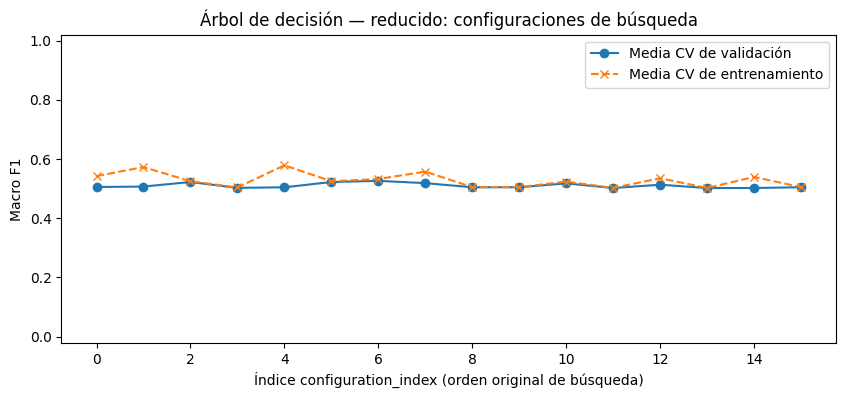

La configuración de índice **6** obtiene la mejor media CV. Las curvas muestran ajuste y validación dentro de entrenamiento; el eje no es una escala de complejidad.

### Diagnóstico en entrenamiento y comparación en validación fija

,partición,Macro F1,Accuracy
0,train,0.533612,0.526029
1,validation,0.533385,0.525733


,f1,precision,precision_undefined,recall,support
Low,0.544566,0.505763,False,0.589817,2455
Medium,0.484244,0.494094,False,0.474779,3172
High,0.571346,0.622404,False,0.52803,1873


Macro F1 = **0.533385**, Accuracy = **0.525733**. High: Precision **0.622404** y Recall **0.528030**. El soporte representa registros de cada etiqueta.

Brecha Macro F1 entrenamiento−validación = **0.000227**. Una brecha positiva señala un posible sobreajuste; una brecha pequeña tampoco garantiza generalización externa.

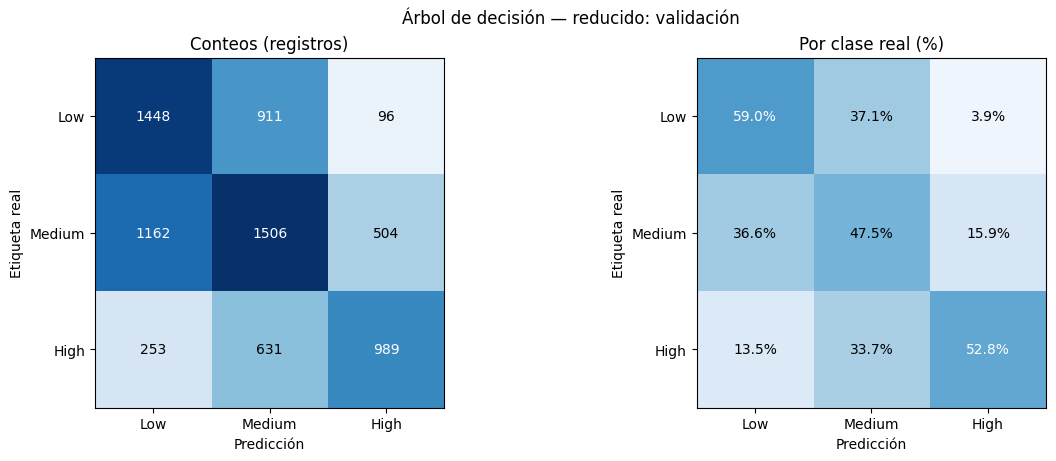

High→Low: **253**; High→Medium: **631**. Low→High: **96**; Medium→High: **504**. Los primeros son falsos negativos de High y los últimos falsos positivos. La normalización muestra la fracción de cada clase real. Un mayor Recall puede acompañarse de menor Precision; la matriz permite localizar ese compromiso.

,fits,inference_includes,search_and_refit_seconds,selected_refit_seconds,started_utc,train_inference_seconds,validation_inference_seconds
0,81,predict and predict_proba; full pipeline,24.96881,0.165261,2026-10-09T19:55:29.145289+00:00,0.070567,0.018399


Los tiempos incluyen el preprocesamiento. Son observaciones de esta ejecución y equipo, no constantes reproducibles.

### Interpretabilidad

,feature,importance
1,numericas__Weekly_GenAI_Hours,0.831893
12,categoricas__Year_of_Study_Graduate,0.071267
26,categoricas__Institutional_Policy_Strict_Ban,0.034504
11,categoricas__Year_of_Study_Freshman,0.031996
0,numericas__Pre_Semester_GPA,0.023043
4,numericas__Perceived_AI_Dependency,0.006068
22,categoricas__Prompt_Engineering_Skill_Beginner,0.000993
3,numericas__Traditional_Study_Hours,0.000236
7,categoricas__Major_Category_Business,0.000000
2,numericas__Tool_Diversity,0.000000


,feature,mean,std,repeat_0,repeat_1,repeat_2,repeat_3,repeat_4
0,Major_Category,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,Tool_Diversity,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,Prompt_Engineering_Skill,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,Primary_Use_Case,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,Paid_Subscription,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
11,Anxiety_Level_During_Exams,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,Perceived_AI_Dependency,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,Traditional_Study_Hours,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,Pre_Semester_GPA,0.005665,0.001933,0.004234,0.009283,0.005923,0.003945,0.004940
10,Institutional_Policy,0.006890,0.001108,0.006819,0.006588,0.006178,0.005860,0.009004


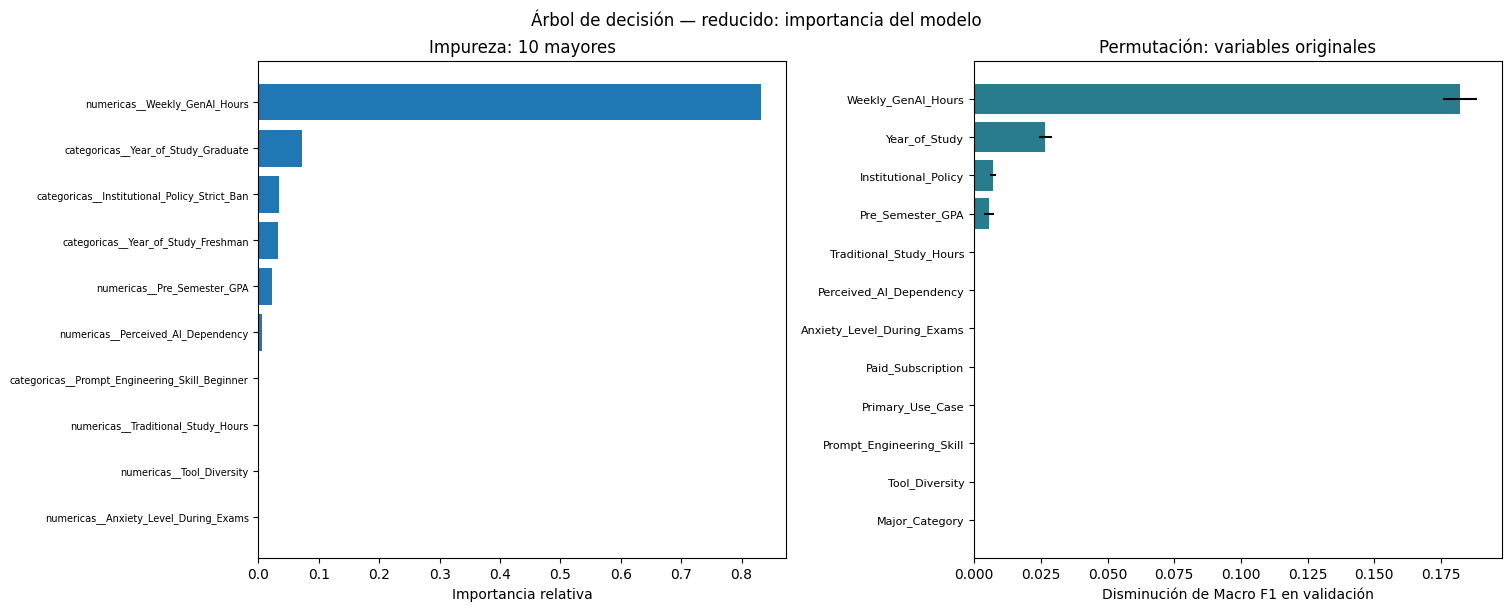

Mayor importancia por permutación: **Weekly_GenAI_Hours**, caída media **0.182192**. Las barras de error son DE de cinco permutaciones, no intervalos de confianza. Impureza puede favorecer variables con más cortes; predictores correlacionados pueden repartirse o enmascarar importancia por permutación. Estas medidas describen el modelo, no causalidad ni la fórmula de burnout.

Árbol seleccionado: profundidad **5**, **63 nodos** y **32 hojas**. La vista siguiente muestra la raíz y dos niveles descendientes; el resto se indica truncado. Las reglas completas están en `reglas.txt` y pertenecen al ganador.

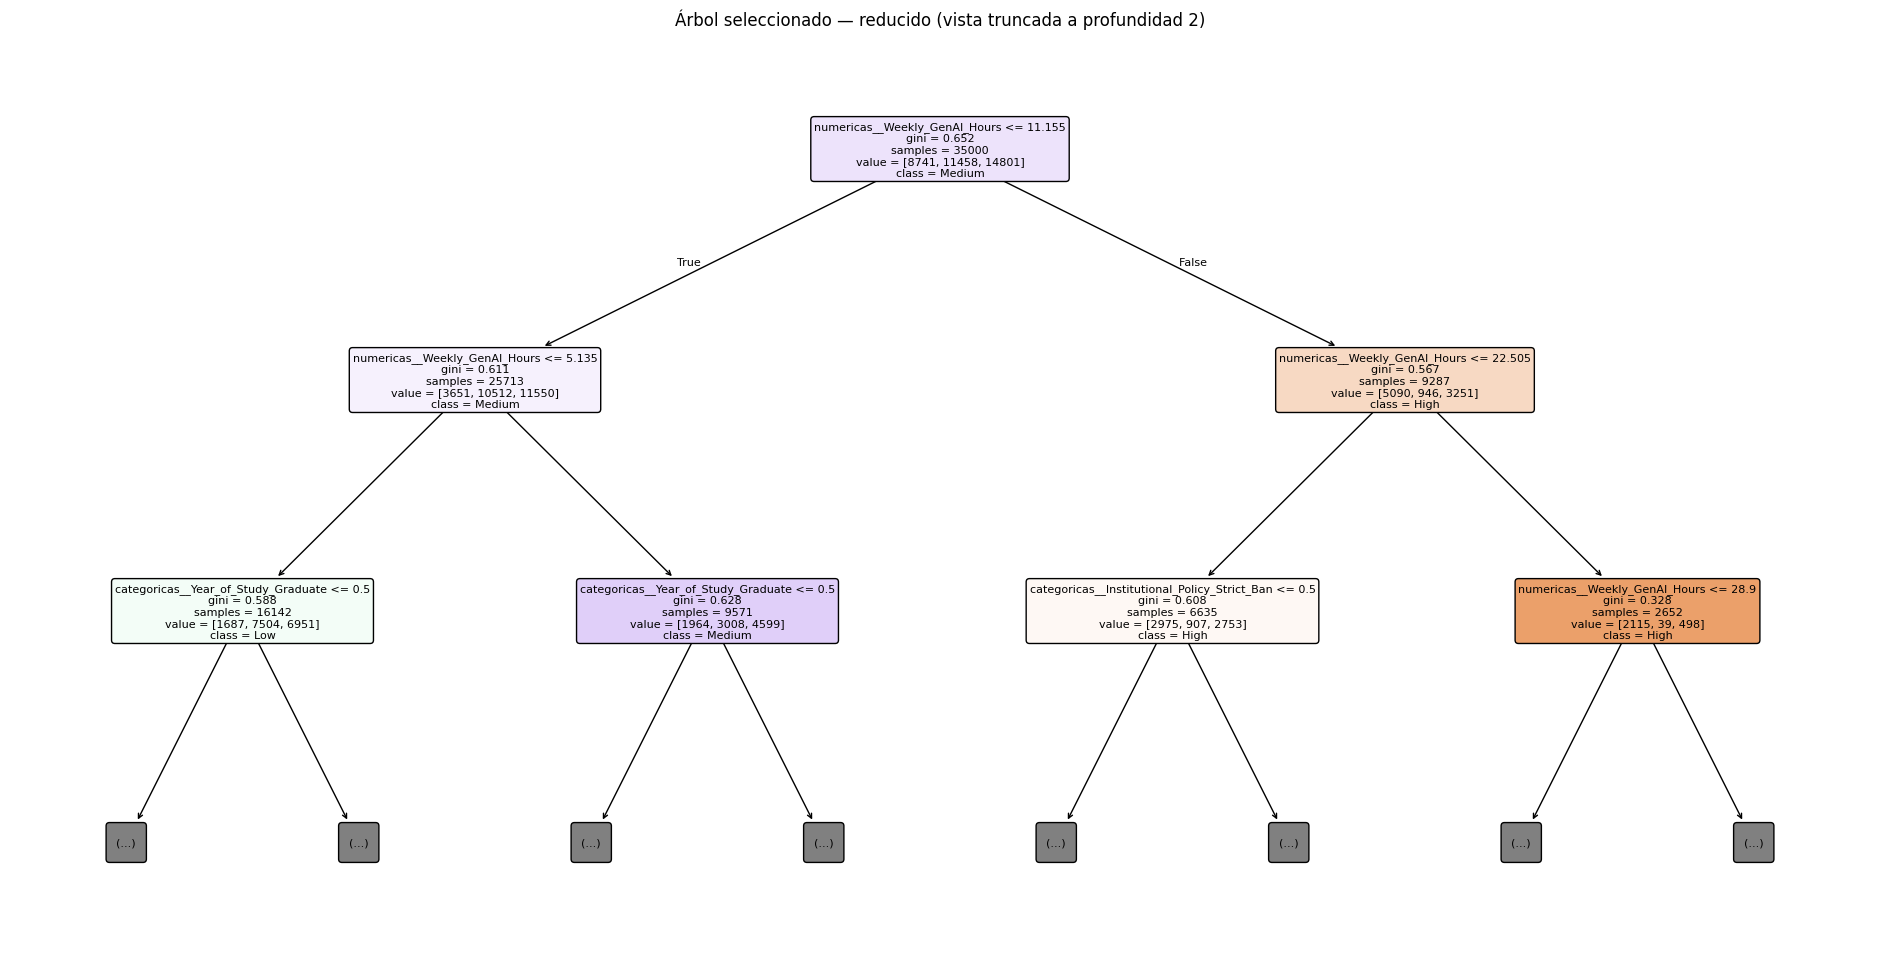

Raíz: **numericas__Weekly_GenAI_Hours ≤ 11.1550**, Gini **0.6516**, **35000 muestras**. La rama izquierda cumple el umbral; la derecha lo supera. `value` y Gini reflejan pesos si se seleccionó `balanced`; el orden real de clases es **['High', 'Low', 'Medium']**. Cada hoja predice la clase de mayor proporción ponderada.

### Conclusión del experimento
Macro F1 de validación **0.533385**; Recall de High **0.528030**. El resultado corresponde a etiquetas de registros completos de este CSV. Un desempeño alto podría reflejar reglas desconocidas de construcción de la etiqueta; no acredita detección anticipada ni utilidad clínica.

### Categorías desconocidas y controles de entrada

,variable,registros_desconocidos_validación
0,Major_Category,0
1,Year_of_Study,0
2,Primary_Use_Case,0
3,Prompt_Engineering_Skill,0
4,Institutional_Policy,0


Se observaron **0 incidencias** de categorías de validación ausentes en entrenamiento. La política `handle_unknown="ignore"` representa una desconocida mediante ceros; su prueba dirigida utiliza un caso artificial separado.

### Búsqueda y configuración seleccionada

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_clasificador__n_estimators,param_clasificador__min_samples_leaf,param_clasificador__max_features,param_clasificador__max_depth,param_clasificador__class_weight,params,...,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score,configuration_index
0,6.085745,0.064600,0.098531,0.005435,150,20,0.5,8.0,NaN,"{""clasificador__class_weight"":null,""clasificad...",...,0.005011,1,0.567113,0.564021,0.564762,0.564508,0.564716,0.565024,0.001077,6
1,3.656160,0.091986,0.135901,0.005652,150,20,sqrt,NaN,NaN,"{""clasificador__class_weight"":null,""clasificad...",...,0.005034,2,0.624231,0.620268,0.623202,0.622186,0.621581,0.622293,0.001357,4
2,8.894101,0.121369,0.143179,0.006317,150,20,0.5,NaN,NaN,"{""clasificador__class_weight"":null,""clasificad...",...,0.003767,3,0.647166,0.641333,0.646435,0.644388,0.644284,0.644721,0.002035,7
3,4.438942,0.129443,0.178321,0.007322,150,5,sqrt,16.0,balanced,"{""clasificador__class_weight"":""balanced"",""clas...",...,0.002132,4,0.775309,0.778842,0.774762,0.780424,0.782793,0.778426,0.003046,5
4,4.866497,0.262144,0.191167,0.010440,150,5,sqrt,NaN,balanced,"{""clasificador__class_weight"":""balanced"",""clas...",...,0.003016,5,0.825116,0.825860,0.823927,0.826670,0.827726,0.825860,0.001298,1
5,12.087134,0.398031,0.206251,0.006669,150,1,0.5,16.0,balanced,"{""clasificador__class_weight"":""balanced"",""clas...",...,0.004209,6,0.953095,0.957251,0.954597,0.957396,0.955824,0.955633,0.001629,9
6,11.934845,0.196960,0.207638,0.014505,150,1,0.5,16.0,NaN,"{""clasificador__class_weight"":null,""clasificad...",...,0.006250,7,0.947143,0.950743,0.947744,0.950712,0.947466,0.948762,0.001617,2
7,2.792996,0.112636,0.095858,0.004242,150,1,sqrt,8.0,NaN,"{""clasificador__class_weight"":null,""clasificad...",...,0.005023,8,0.568233,0.567419,0.568379,0.563835,0.566229,0.566819,0.001676,3
8,2.817766,0.070996,0.101998,0.010134,150,20,sqrt,8.0,NaN,"{""clasificador__class_weight"":null,""clasificad...",...,0.007091,9,0.556739,0.555790,0.557724,0.556033,0.555925,0.556442,0.000720,0
9,5.139730,0.144157,0.210715,0.005265,150,1,sqrt,16.0,NaN,"{""clasificador__class_weight"":null,""clasificad...",...,0.004211,10,0.952852,0.956362,0.955356,0.954358,0.953754,0.954537,0.001223,8


,parámetro,valor
0,clasificador__class_weight,None
1,clasificador__max_depth,8
2,clasificador__max_features,0.5
3,clasificador__min_samples_leaf,20
4,clasificador__n_estimators,150


Se completaron **12 configuraciones** y **61 ajustes**. CV Macro F1 = **0.537119**, DE = **0.005011**. Esta media selecciona hiperparámetros; no evalúa independientemente al ganador. La desviación entre cinco pliegues no es un intervalo de confianza.

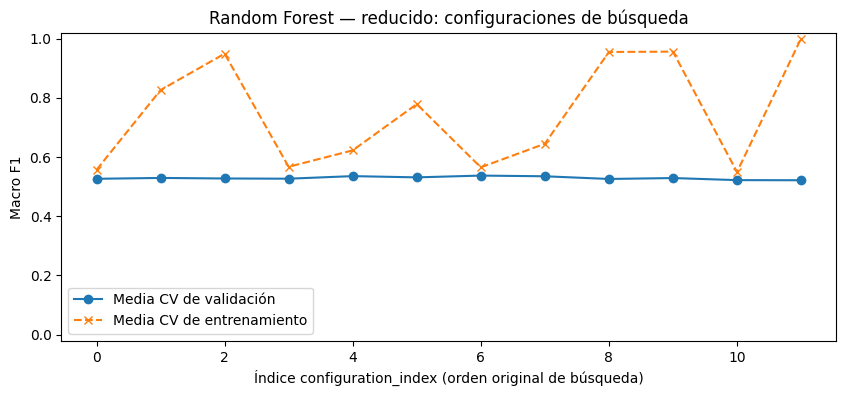

La configuración de índice **6** obtiene la mejor media CV. Las curvas muestran ajuste y validación dentro de entrenamiento; el eje no es una escala de complejidad.

### Diagnóstico en entrenamiento y comparación en validación fija

,partición,Macro F1,Accuracy
0,train,0.561689,0.559371
1,validation,0.536140,0.533067


,f1,precision,precision_undefined,recall,support
Low,0.509679,0.533393,False,0.487984,2455
Medium,0.534072,0.485795,False,0.593001,3172
High,0.56467,0.664978,False,0.490657,1873


Macro F1 = **0.536140**, Accuracy = **0.533067**. High: Precision **0.664978** y Recall **0.490657**. El soporte representa registros de cada etiqueta.

Brecha Macro F1 entrenamiento−validación = **0.025549**. Una brecha positiva señala un posible sobreajuste; una brecha pequeña tampoco garantiza generalización externa.

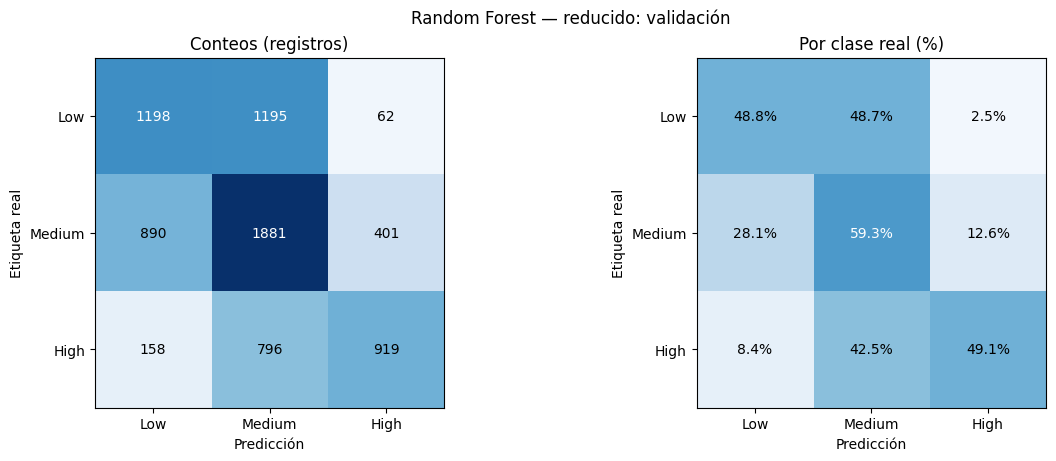

High→Low: **158**; High→Medium: **796**. Low→High: **62**; Medium→High: **401**. Los primeros son falsos negativos de High y los últimos falsos positivos. La normalización muestra la fracción de cada clase real. Un mayor Recall puede acompañarse de menor Precision; la matriz permite localizar ese compromiso.

,fits,inference_includes,search_and_refit_seconds,selected_refit_seconds,started_utc,train_inference_seconds,validation_inference_seconds
0,61,predict and predict_proba; full pipeline,573.759455,8.318727,2026-10-09T20:05:11.560690+00:00,0.699187,0.172047


Los tiempos incluyen el preprocesamiento. Son observaciones de esta ejecución y equipo, no constantes reproducibles.

### Interpretabilidad

,feature,importance
1,numericas__Weekly_GenAI_Hours,0.584236
4,numericas__Perceived_AI_Dependency,0.150450
0,numericas__Pre_Semester_GPA,0.058751
12,categoricas__Year_of_Study_Graduate,0.050426
3,numericas__Traditional_Study_Hours,0.038563
11,categoricas__Year_of_Study_Freshman,0.027535
5,numericas__Anxiety_Level_During_Exams,0.024361
26,categoricas__Institutional_Policy_Strict_Ban,0.021971
2,numericas__Tool_Diversity,0.005736
14,categoricas__Year_of_Study_Senior,0.005579


,feature,mean,std,repeat_0,repeat_1,repeat_2,repeat_3,repeat_4
11,Anxiety_Level_During_Exams,-0.001081,0.000928,0.000742,-0.001638,-0.001341,-0.001364,-0.001803
5,Prompt_Engineering_Skill,-0.000472,0.000353,-0.000643,-0.000786,-0.000789,-0.000261,0.000119
8,Traditional_Study_Hours,-0.000377,0.002144,0.001648,0.001174,-0.002025,-0.003781,0.001099
6,Tool_Diversity,0.000191,0.000724,0.000803,0.000296,0.000201,0.000821,-0.001165
0,Major_Category,0.000246,0.000446,0.000608,-0.000613,0.000430,0.000547,0.000261
7,Paid_Subscription,0.000695,0.000989,-0.000222,-0.000497,0.000656,0.001370,0.002168
4,Primary_Use_Case,0.001352,0.000426,0.000819,0.002044,0.001119,0.001181,0.001595
2,Pre_Semester_GPA,0.006140,0.001374,0.004723,0.005589,0.008739,0.005526,0.006124
10,Institutional_Policy,0.008398,0.001126,0.008397,0.010498,0.007565,0.008226,0.007303
9,Perceived_AI_Dependency,0.011680,0.002373,0.011517,0.012300,0.012075,0.014942,0.007565


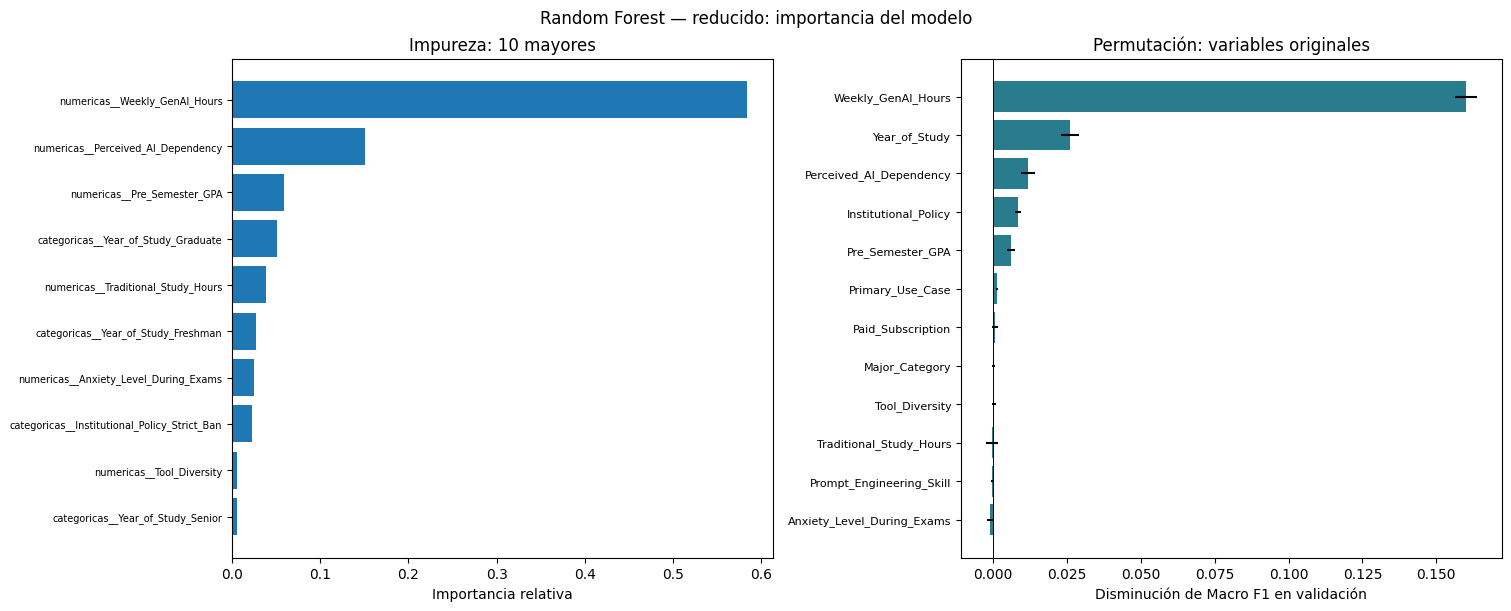

Mayor importancia por permutación: **Weekly_GenAI_Hours**, caída media **0.160036**. Las barras de error son DE de cinco permutaciones, no intervalos de confianza. Impureza puede favorecer variables con más cortes; predictores correlacionados pueden repartirse o enmascarar importancia por permutación. Estas medidas describen el modelo, no causalidad ni la fórmula de burnout.

Bosque de **150 árboles**, **50610 nodos** en total y profundidad media **8.00**. Agrega árboles ajustados sobre muestras bootstrap y subconjuntos de variables, pudiendo representar interacciones y reducir variabilidad respecto de un árbol individual. Su decisión resulta menos simple de explicar.

### Conclusión del experimento
Macro F1 de validación **0.536140**; Recall de High **0.490657**. El resultado corresponde a etiquetas de registros completos de este CSV. Un desempeño alto podría reflejar reglas desconocidas de construcción de la etiqueta; no acredita detección anticipada ni utilidad clínica.

In [3]:
for modelo in core.MODELOS:
    presentar_modelo(modelo, "reducido", directory)

## Límite del contraste

Una caída pequeña no elimina circularidad; una caída grande tampoco identifica la fórmula de burnout. No se cambia el protocolo principal ni se usan resultados de prueba.